In [1]:
import torch
from diffusion.approaches.matching.prob_paths import (
    GaussianCondProbPath,
    LinearAlpha,
    LinearBeta,
)
from diffusion.sampleables.mnist_sampleable import MNISTSampleable
from diffusion.architectures.backbones.res_unet import ResUnet
from diffusion.approaches.matching.flow_generator import FlowGenerator, ScoreGenerator
from diffusion.architectures.classifiers.mnist_classifier import MNISTClassifier
from diffusion.evaluation.evaluate import (
    compute_samples,
    plot_metrics_per_class,
    visualize_samples_per_class,
    compute_features,
    evaluate_features,
)


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable(train=True)

path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=1,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)
backbone.load_state_dict(torch.load("./models/backbone_flow_bili.pt"))

encoder = MNISTClassifier(num_classes=sampeable.num_classes).to(device)
encoder.load_state_dict(torch.load("./models/encoder.pt"))

<All keys matched successfully>

In [ ]:
p_data_test = MNISTSampleable(train=False)


100%|██████████| 9/9 [00:01<00:00,  6.15it/s]


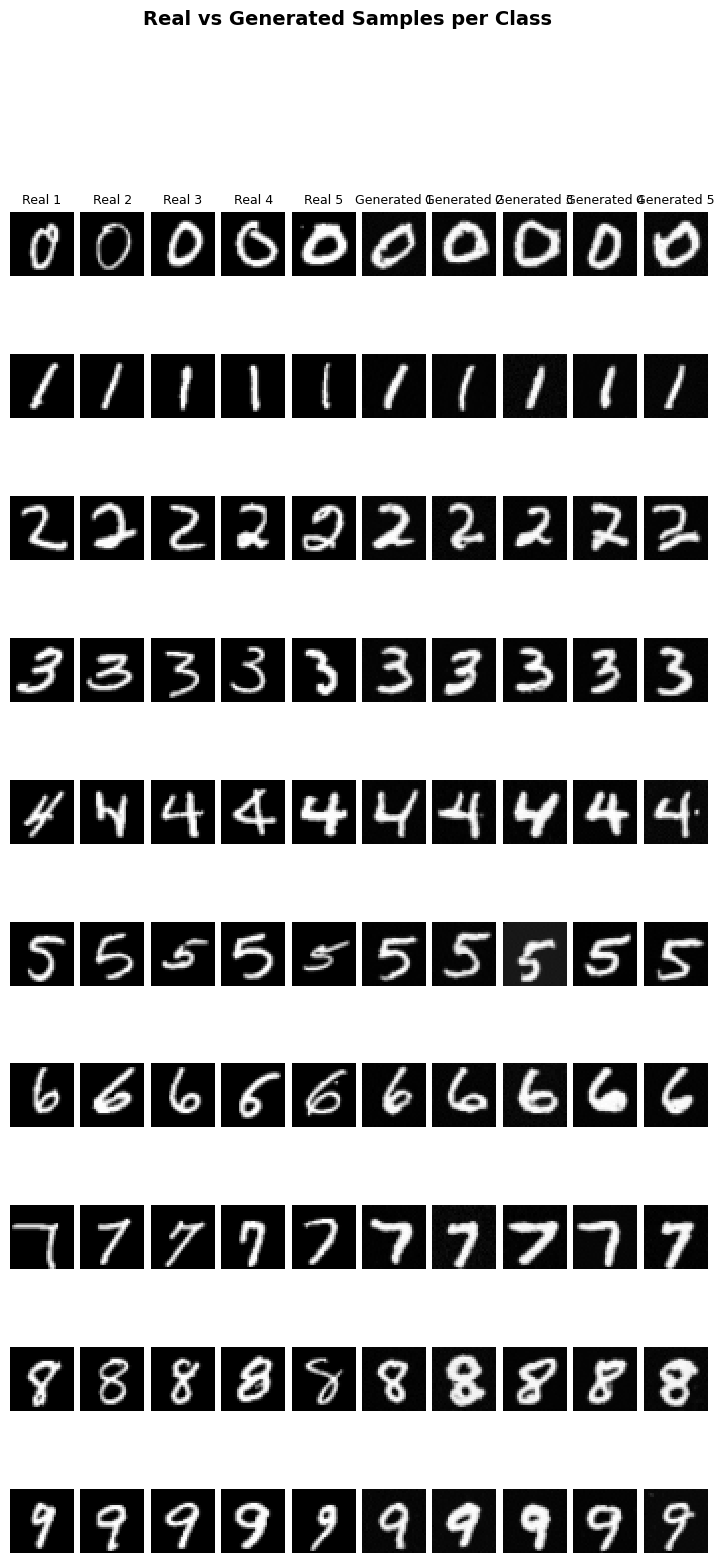

In [6]:
num_timesteps = 10
samples_per_class = 200
guidance_scale = 2.0

flow_generator = FlowGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_flow, real_list_flow = compute_samples(
    generator=flow_generator,
    p_data=p_data_test,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

visualize_samples_per_class(x1_list_flow, real_list_flow)

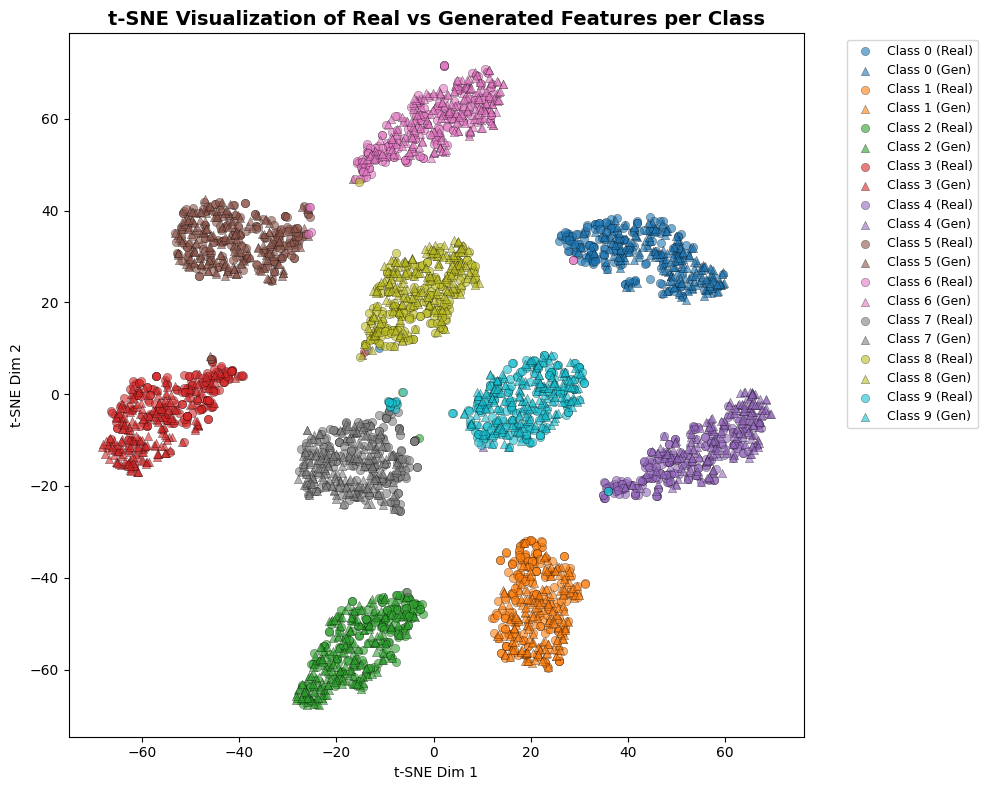

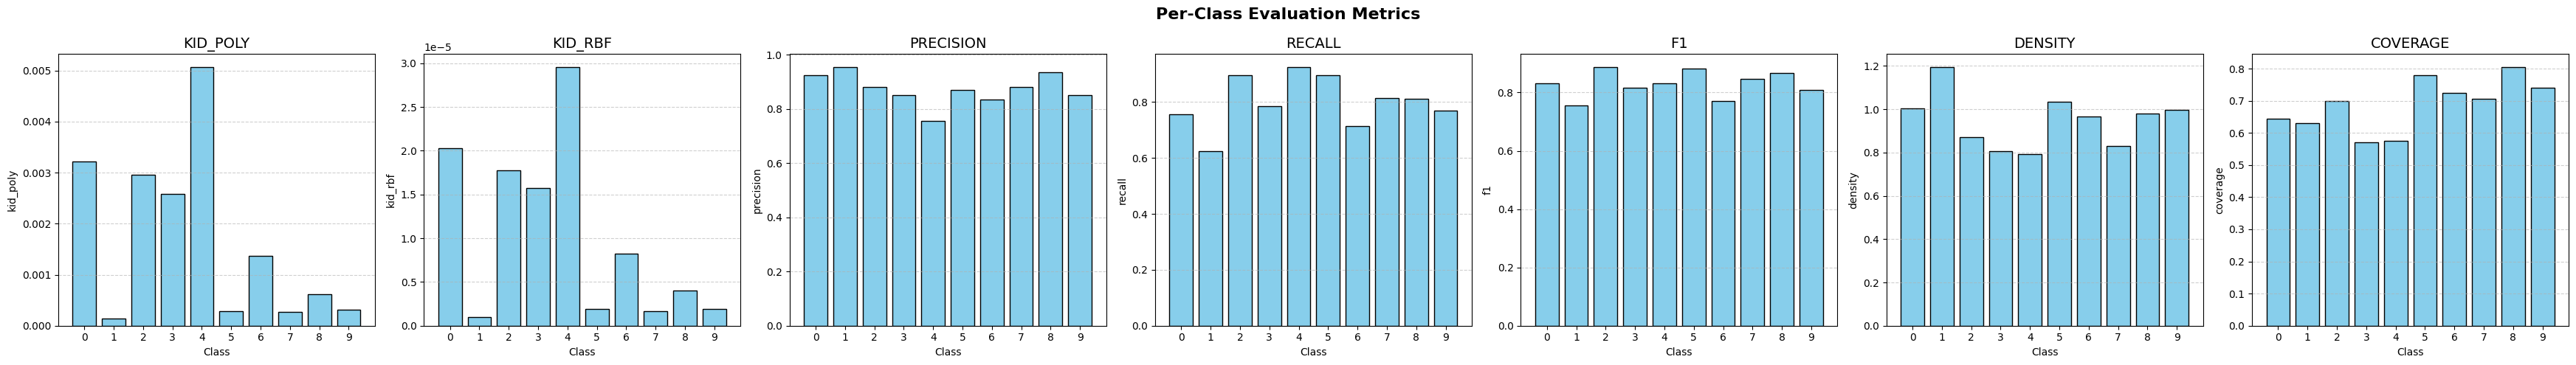

In [7]:
from diffusion.evaluation.evaluate import visualize_tsne_per_class


x1_features_flow, real_features_flow = compute_features(
    x1_list_flow, real_list_flow, encoder
)

visualize_tsne_per_class(x1_features_flow, real_features_flow)

metrics_per_class_flow = evaluate_features(x1_features_flow, real_features_flow)

plot_metrics_per_class(metrics_per_class_flow)

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:02<00:00,  3.05it/s]


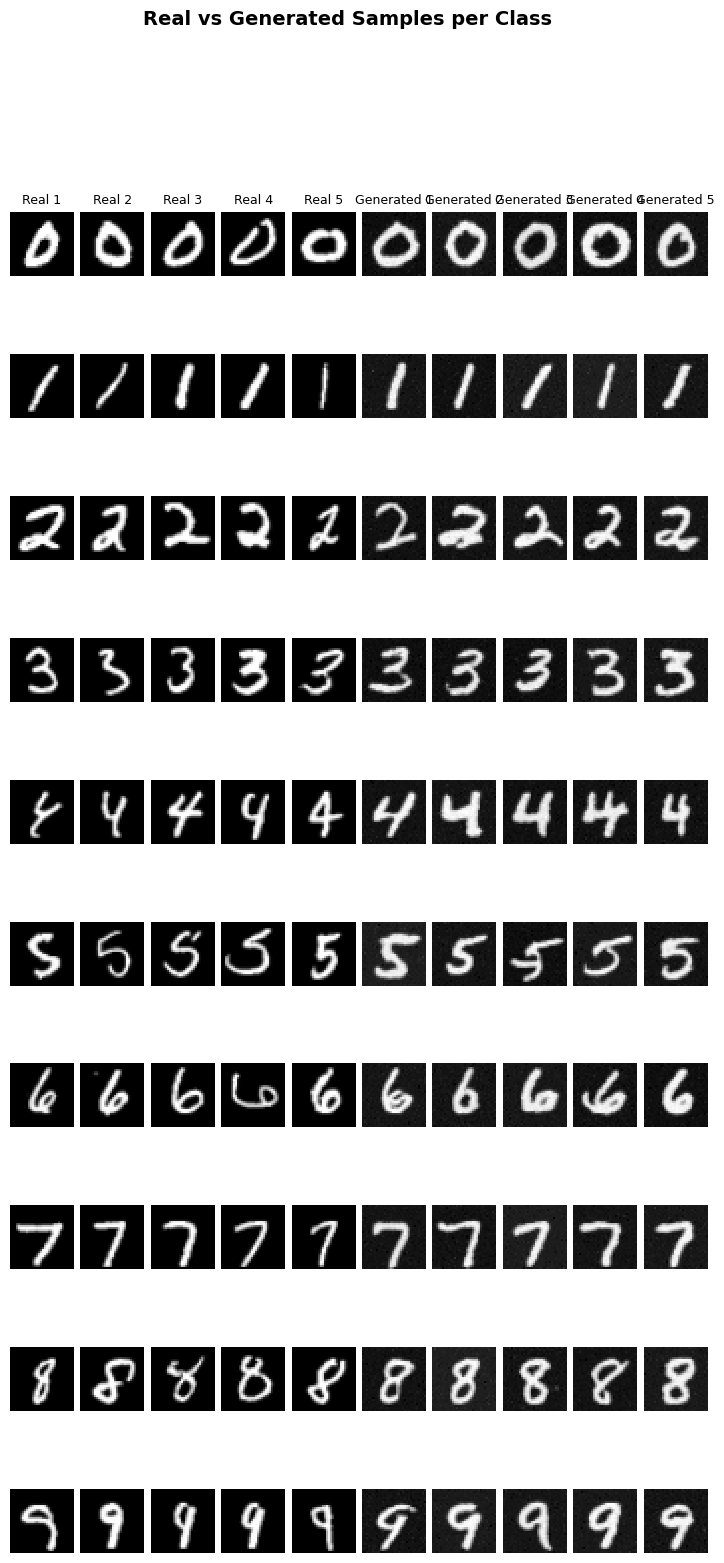

In [8]:
num_timesteps = 10
samples_per_class = 200
guidance_scale = 2.0

flow_generator = ScoreGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_score, real_list_score = compute_samples(
    generator=flow_generator,
    p_data=p_data_test,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

visualize_samples_per_class(x1_list_score, real_list_score)

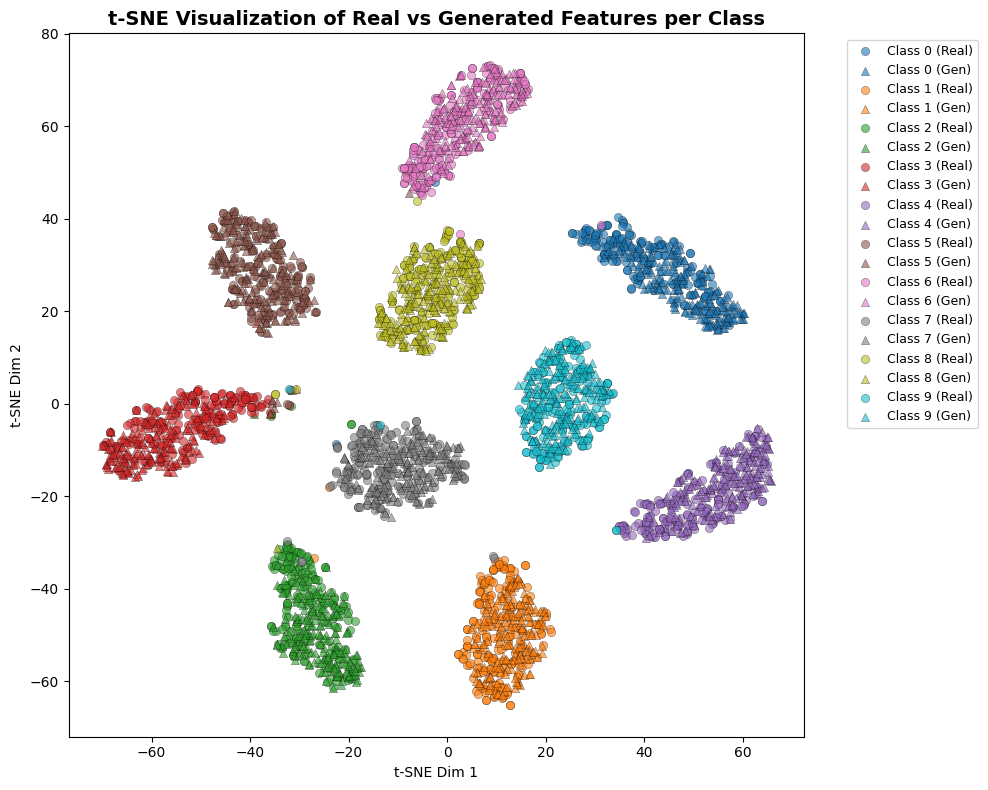

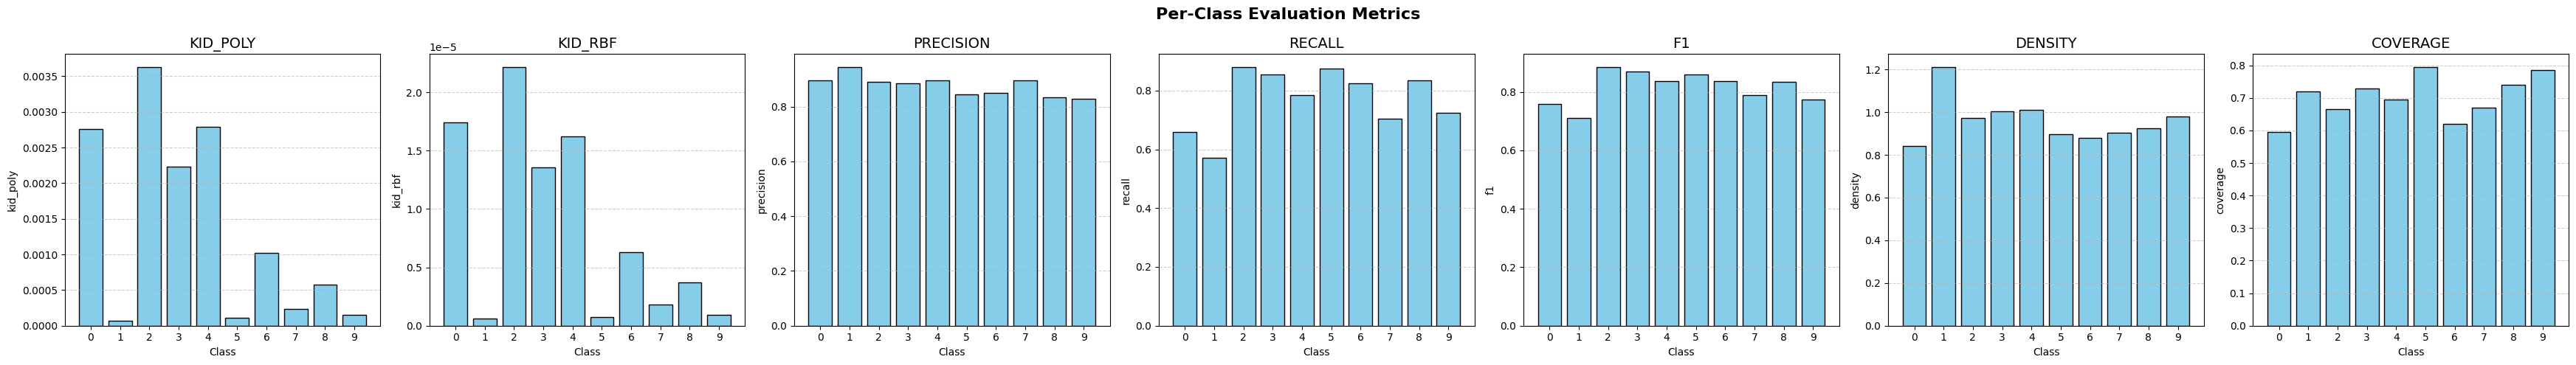

In [10]:
x1_features_score, real_features_score = compute_features(
    x1_list_score, real_list_score, encoder
)

visualize_tsne_per_class(x1_features_score, real_features_score)

metrics_per_class_score = evaluate_features(x1_features_score, real_features_score)

plot_metrics_per_class(metrics_per_class_score)

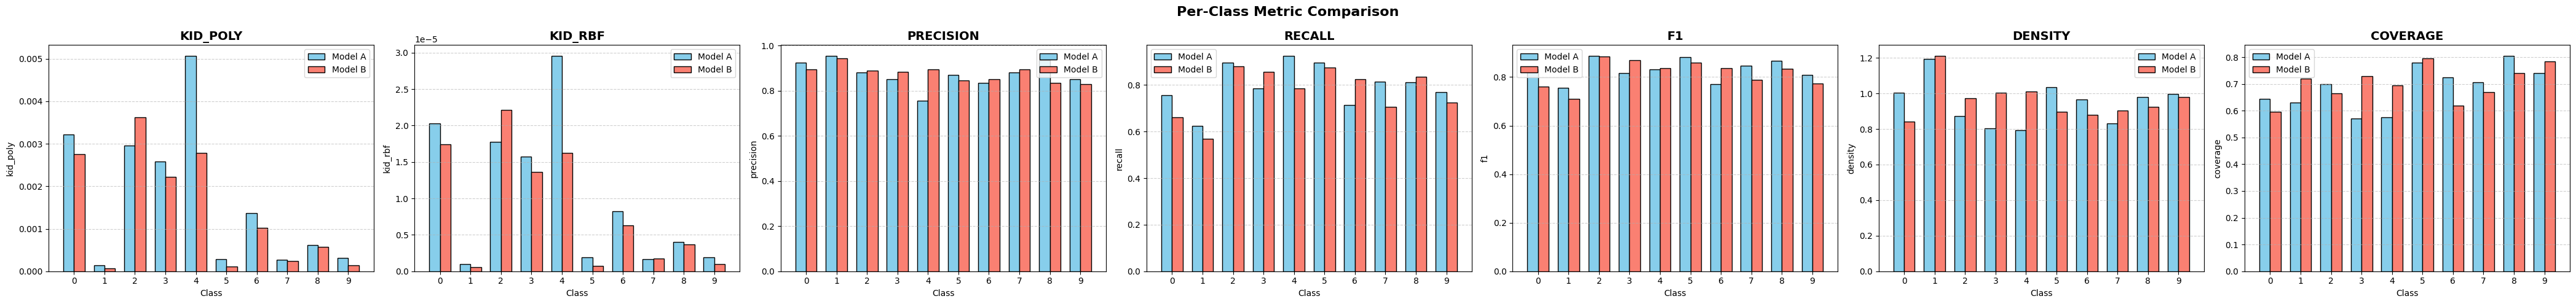

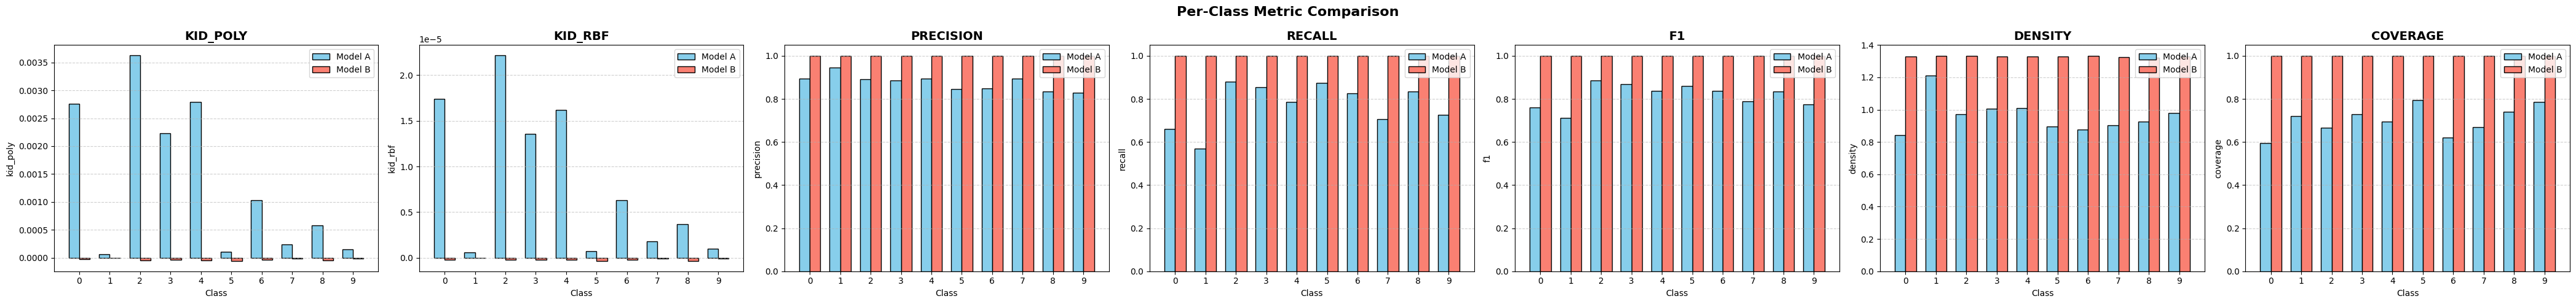

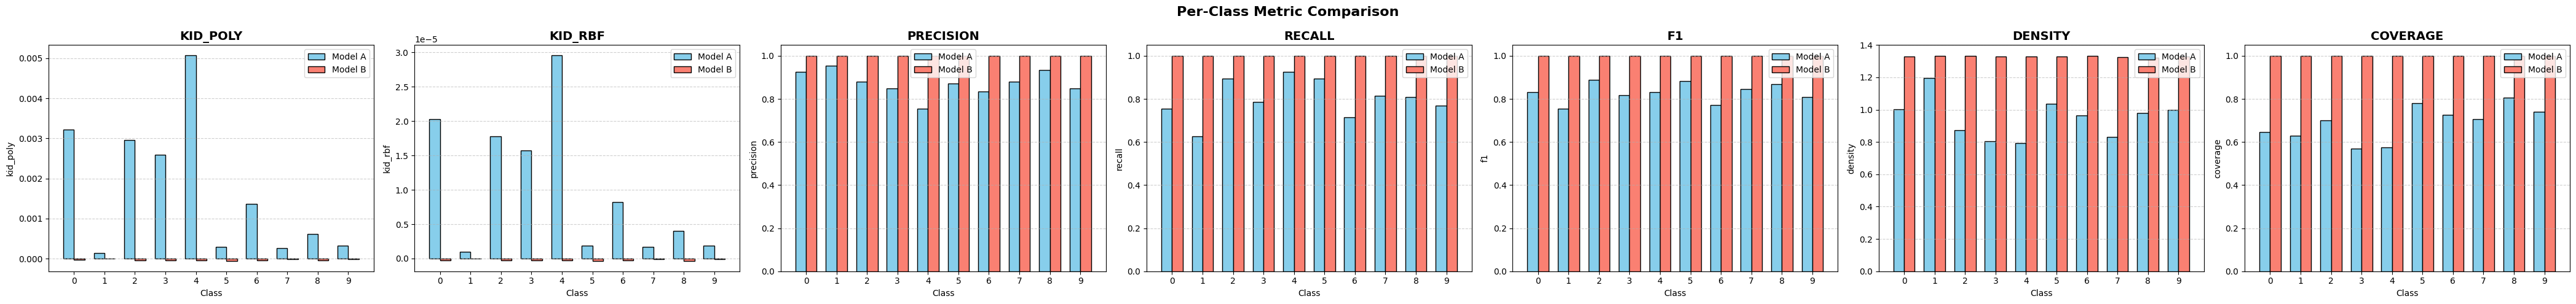

In [11]:
from diffusion.evaluation.evaluate import compare_metrics_per_class

metrics_per_class_perfect = evaluate_features(x1_features_score, x1_features_score)

compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_score)
compare_metrics_per_class(metrics_per_class_score, metrics_per_class_perfect)
compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_perfect)